# Pulsation modes: radial, spheroidal, and toroidal

SPICE represents non-radial pulsations as a sum of three **vector spherical harmonic** (VSH) components, each driven by its own Fourier series in time:

$$\vec{\xi}(t, \theta, \phi) \;=\; a_r(t)\, R_\ell^m \;+\; a_s(t)\, S_\ell^m \;+\; a_t(t)\, T_\ell^m$$

with the three basis vectors

| component | definition | physical meaning |
|---|---|---|
| **Radial** $R_\ell^m$    | $Y_\ell^m\,\hat{r}$ | breathing motion along the radius — p-modes |
| **Spheroidal** $S_\ell^m$ | $\nabla_\perp Y_\ell^m$ | horizontal gradient flow — g-modes, solar-like |
| **Toroidal** $T_\ell^m$   | $\hat{r}\times\nabla_\perp Y_\ell^m$ | horizontal shear (curl) — r-modes |

In `add_pulsation()` you pass a `(3, n_terms, 2)` Fourier array whose rows are `[radial, spheroidal, toroidal]`, and each `(n_terms, 2)` block holds `[amplitude, phase]` pairs.

This notebook walks through each of the three components in isolation, then shows how to mix them to reproduce the horizontal-to-radial displacement ratio expected for p-modes and g-modes.

## 1. Setup

We build a single icosphere model and then re-use it for each mode by calling `add_pulsation` with different Fourier-parameter arrays.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

from spice.models import IcosphereModel
from spice.models.mesh_transform import add_pulsation, evaluate_pulsations, reset_pulsations
from spice.models.utils import horizontal_to_radial_ratio
from spice.plots import plot_3D

%matplotlib inline

In [2]:
# A small icosphere is enough to see each pattern clearly while keeping the
# JAX compile-times short. Bump n_vertices if you want a smoother sphere.
base_mesh = IcosphereModel.construct(
    n_vertices=642,
    radius=1.0,
    mass=1.0,
    parameters=jnp.array([5700.0, 4.4]),
    parameter_names=["teff", "log_g"],
    max_pulsation_mode=4,
    max_fourier_order=3,
)

print(f"Mesh elements: {base_mesh.d_centers.shape[0]}")
print(f"Max (l, m) supported: ({base_mesh.max_pulsation_mode - 1}, "
      f"{base_mesh.max_pulsation_mode - 1})")

[spice] Constructing IcosphereModel (642 vertices)...
[spice] IcosphereModel constructed in 1.2 s
Mesh elements: 1280
Max (l, m) supported: (3, 3)


In [3]:
def vsh_fourier(amp_r=0.0, amp_s=0.0, amp_t=0.0, phase=0.0):
    """Build a (3, 1, 2) Fourier-parameter array for a single VSH mode.

    The three rows drive the radial (R_lm), spheroidal (S_lm), and toroidal
    (T_lm) VSH components respectively. Each row holds one (amplitude, phase)
    pair — all amplitudes are in units of the stellar radius.
    """
    return jnp.array([
        [[amp_r, phase]],
        [[amp_s, phase]],
        [[amp_t, phase]],
    ])


def velocity_arrows(ax, mesh_eval, *, stride=3, arrow_scale=0.35, visible_only=True):
    """Overlay pulsation velocity vectors on an existing 3D axis."""
    centers = np.asarray(mesh_eval.d_centers)
    vel = np.asarray(mesh_eval.pulsation_velocities)
    mus = np.asarray(mesh_eval.mus)

    idx = np.arange(0, len(centers), stride)
    if visible_only:
        idx = idx[mus[idx] > 0]

    vel_mag = np.linalg.norm(vel, axis=1)
    max_mag = vel_mag.max() + 1e-10
    scaled = vel[idx] / max_mag * arrow_scale
    colors = cm.inferno(Normalize(0, max_mag)(vel_mag[idx]))

    for (x, y, z), (dx, dy, dz), col in zip(centers[idx], scaled, colors):
        ax.quiver(x, y, z, dx, dy, dz, color=col,
                  arrow_length_ratio=0.3, linewidth=1.3)


def decompose_velocity(mesh_eval):
    """Split pulsation velocities into radial + tangential parts."""
    centers = np.asarray(mesh_eval.d_centers)
    vel = np.asarray(mesh_eval.pulsation_velocities)
    r_hat = centers / (np.linalg.norm(centers, axis=1, keepdims=True) + 1e-10)
    v_r = np.sum(vel * r_hat, axis=1, keepdims=True) * r_hat
    v_t = vel - v_r
    return v_r, v_t

## 2. The three VSH components, side by side

We evaluate the same $(\ell=2,\,m=1)$ spherical harmonic three times — once with only the radial amplitude, once with only the spheroidal amplitude, and once with only the toroidal amplitude — and sample each at a quarter of the pulsation period (when the velocity amplitude is maximal for a cosine-driven mode).

- **Radial** arrows point along $\hat{r}$ — pure in/out breathing.
- **Spheroidal** arrows follow $\nabla_\perp Y_\ell^m$ — flow from crests to troughs of the harmonic.
- **Toroidal** arrows are perpendicular to the spheroidal ones — pure horizontal shear/curl.

[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 2.5 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.2 s


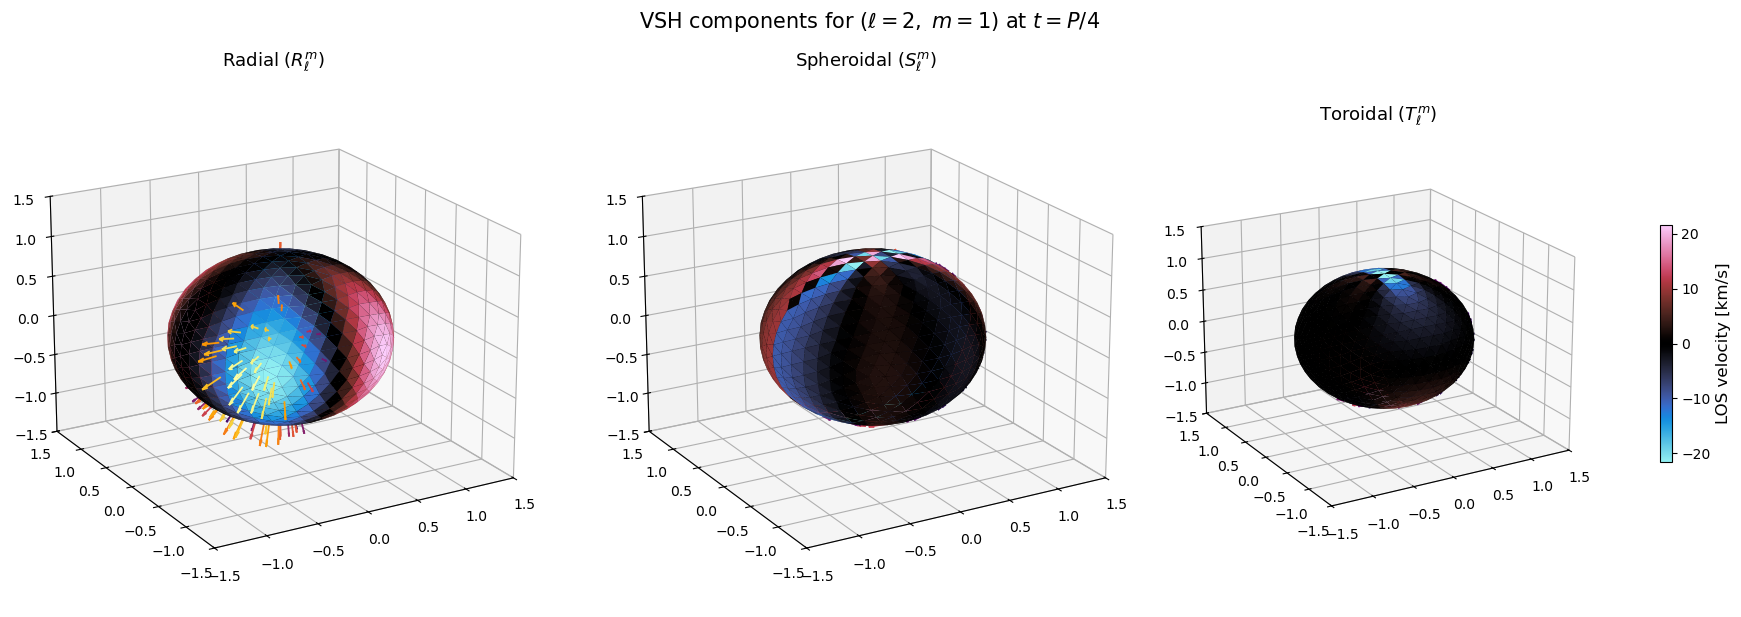

In [4]:
L, M = 2, 1
PERIOD = 0.1   # days
T_SAMPLE = PERIOD / 4.0  # quarter period — peak velocity for a cos-driven amplitude

modes = {
    "Radial ($R_\\ell^m$)":     vsh_fourier(amp_r=0.05),
    "Spheroidal ($S_\\ell^m$)": vsh_fourier(amp_s=0.05),
    "Toroidal ($T_\\ell^m$)":   vsh_fourier(amp_t=0.05),
}

evaluated = {}
for name, fp in modes.items():
    m_pulsating = add_pulsation(
        base_mesh, m_order=M, l_degree=L,
        period=PERIOD, fourier_series_parameters=fp,
    )
    evaluated[name] = evaluate_pulsations(m_pulsating, t=T_SAMPLE)

fig = plt.figure(figsize=(18, 6))
for i, (name, mesh_eval) in enumerate(evaluated.items()):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    plot_3D(mesh_eval, property="los_velocities",
            axes=(fig, ax),
            draw_los_vector=False, draw_rotation_axis=False,
            update_colorbar=(i == 2))
    velocity_arrows(ax, mesh_eval, stride=3, arrow_scale=0.35)
    ax.set_title(name, fontsize=13, pad=10)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    ax.view_init(elev=20, azim=-120)

plt.suptitle(rf"VSH components for $(\ell={L},\; m={M})$ at $t = P/4$",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Sanity check: radial vs tangential velocity budget

Each basis vector is orthogonal, so the pulsation velocity field should live almost entirely in one of the two camps:
- $R_\ell^m$ → radial-only (tangential component vanishes to numerical noise),
- $S_\ell^m$ and $T_\ell^m$ → tangential-only (radial component vanishes to numerical noise).

In [5]:
print(f"{'mode':<32s}{'|v_r|_max [km/s]':>22s}{'|v_t|_max [km/s]':>22s}")
print("-" * 76)
for name, mesh_eval in evaluated.items():
    v_r, v_t = decompose_velocity(mesh_eval)
    print(f"{name:<32s}"
          f"{np.linalg.norm(v_r, axis=1).max():>22.3e}"
          f"{np.linalg.norm(v_t, axis=1).max():>22.3e}")

mode                                  |v_r|_max [km/s]      |v_t|_max [km/s]
----------------------------------------------------------------------------
Radial ($R_\ell^m$)                          2.530e+01             3.911e-06
Spheroidal ($S_\ell^m$)                      8.225e-08             2.530e+01
Toroidal ($T_\ell^m$)                        1.566e-07             2.530e+01


## 3. Radial modes for different $(\ell, m)$

Radial-only pulsation just scales the surface along $\hat{r}$ by $Y_\ell^m$. The shape of the $Y_\ell^m$ pattern sets which parts of the surface move outward/inward at any instant. Below we sweep four examples, keeping only the radial amplitude non-zero.

[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s


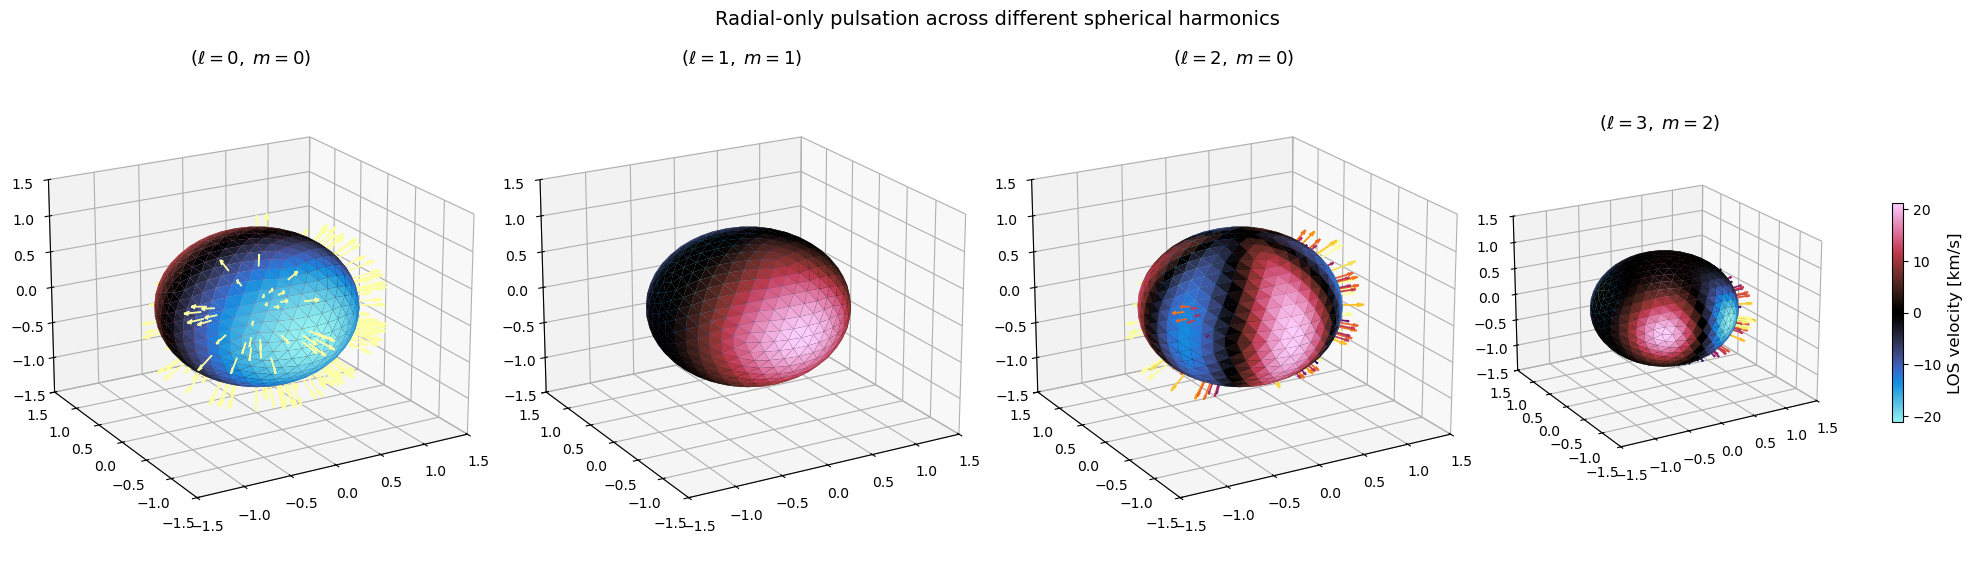

In [6]:
lm_examples = [(0, 0), (1, 1), (2, 0), (3, 2)]

fig = plt.figure(figsize=(20, 5.5))
for i, (l, m) in enumerate(lm_examples):
    fp = vsh_fourier(amp_r=0.05)
    m_pulsating = add_pulsation(
        base_mesh, m_order=m, l_degree=l,
        period=PERIOD, fourier_series_parameters=fp,
    )
    mesh_eval = evaluate_pulsations(m_pulsating, t=T_SAMPLE)

    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    plot_3D(mesh_eval, property="los_velocities",
            axes=(fig, ax),
            draw_los_vector=False, draw_rotation_axis=False,
            update_colorbar=(i == 3))
    velocity_arrows(ax, mesh_eval, stride=4, arrow_scale=0.3)
    ax.set_title(rf"$(\ell={l},\; m={m})$", fontsize=13, pad=8)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    ax.view_init(elev=20, azim=-120)

plt.suptitle("Radial-only pulsation across different spherical harmonics",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Spheroidal (horizontal) modes

The spheroidal basis $S_\ell^m = \nabla_\perp Y_\ell^m$ produces horizontal flow pointing from maxima to minima of $Y_\ell^m$ along the tangential gradient. For $(\ell=0,\,m=0)$ the harmonic is constant and the gradient vanishes, so spheroidal flow is only meaningful for $\ell \ge 1$.

[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s


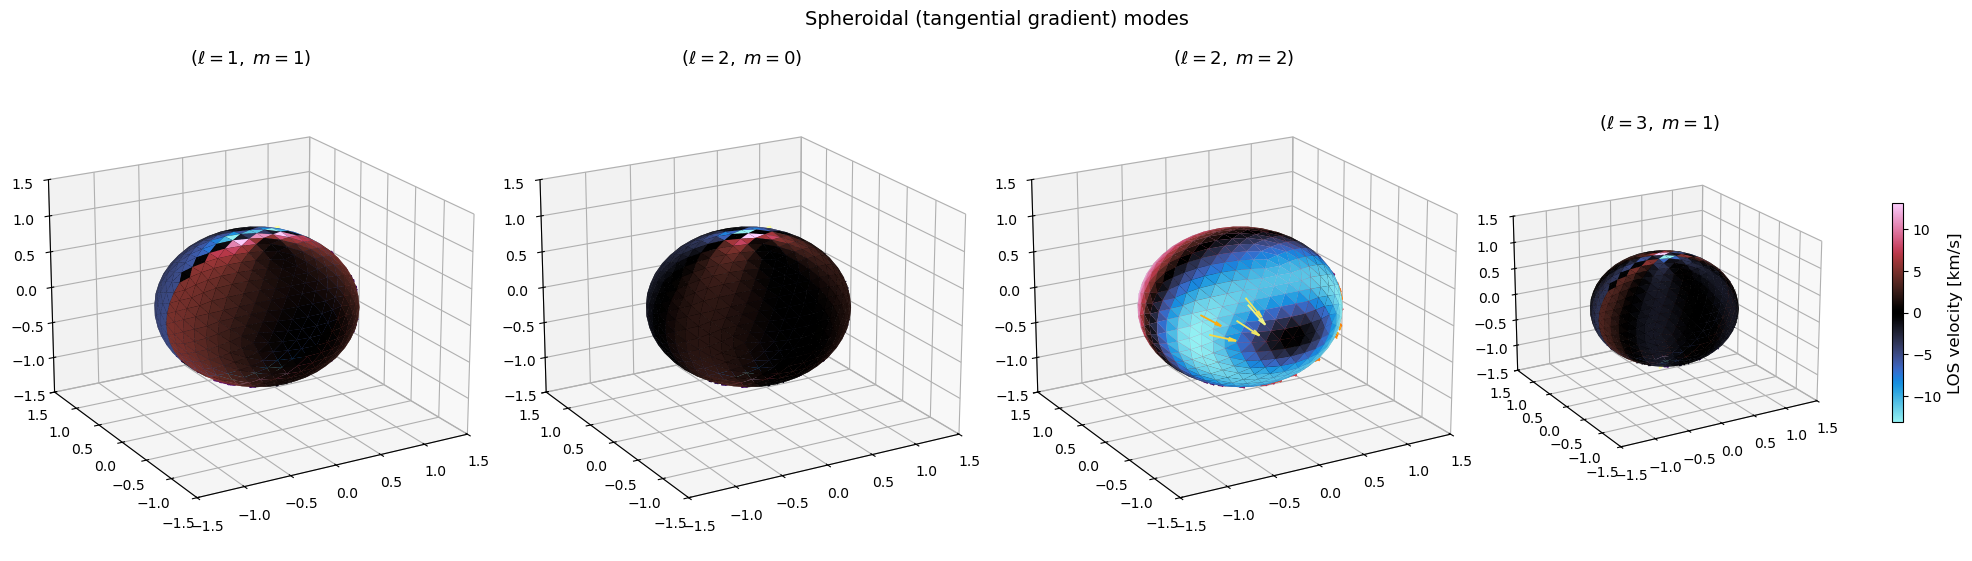

In [7]:
lm_nonradial = [(1, 1), (2, 0), (2, 2), (3, 1)]

fig = plt.figure(figsize=(20, 5.5))
for i, (l, m) in enumerate(lm_nonradial):
    fp = vsh_fourier(amp_s=0.05)
    m_pulsating = add_pulsation(
        base_mesh, m_order=m, l_degree=l,
        period=PERIOD, fourier_series_parameters=fp,
    )
    mesh_eval = evaluate_pulsations(m_pulsating, t=T_SAMPLE)

    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    plot_3D(mesh_eval, property="los_velocities",
            axes=(fig, ax),
            draw_los_vector=False, draw_rotation_axis=False,
            update_colorbar=(i == 3))
    velocity_arrows(ax, mesh_eval, stride=4, arrow_scale=0.3)
    ax.set_title(rf"$(\ell={l},\; m={m})$", fontsize=13, pad=8)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    ax.view_init(elev=20, azim=-120)

plt.suptitle("Spheroidal (tangential gradient) modes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Toroidal (shear) modes

The toroidal basis $T_\ell^m = \hat{r}\times \nabla_\perp Y_\ell^m$ produces horizontal flow perpendicular to the spheroidal direction: it is the **curl** of the spheroidal pattern about the local radial vector. These modes produce no change in the local density or temperature — they're pure horizontal shear, and correspond to r-modes (rotational modes) in stellar oscillation theory.

[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s


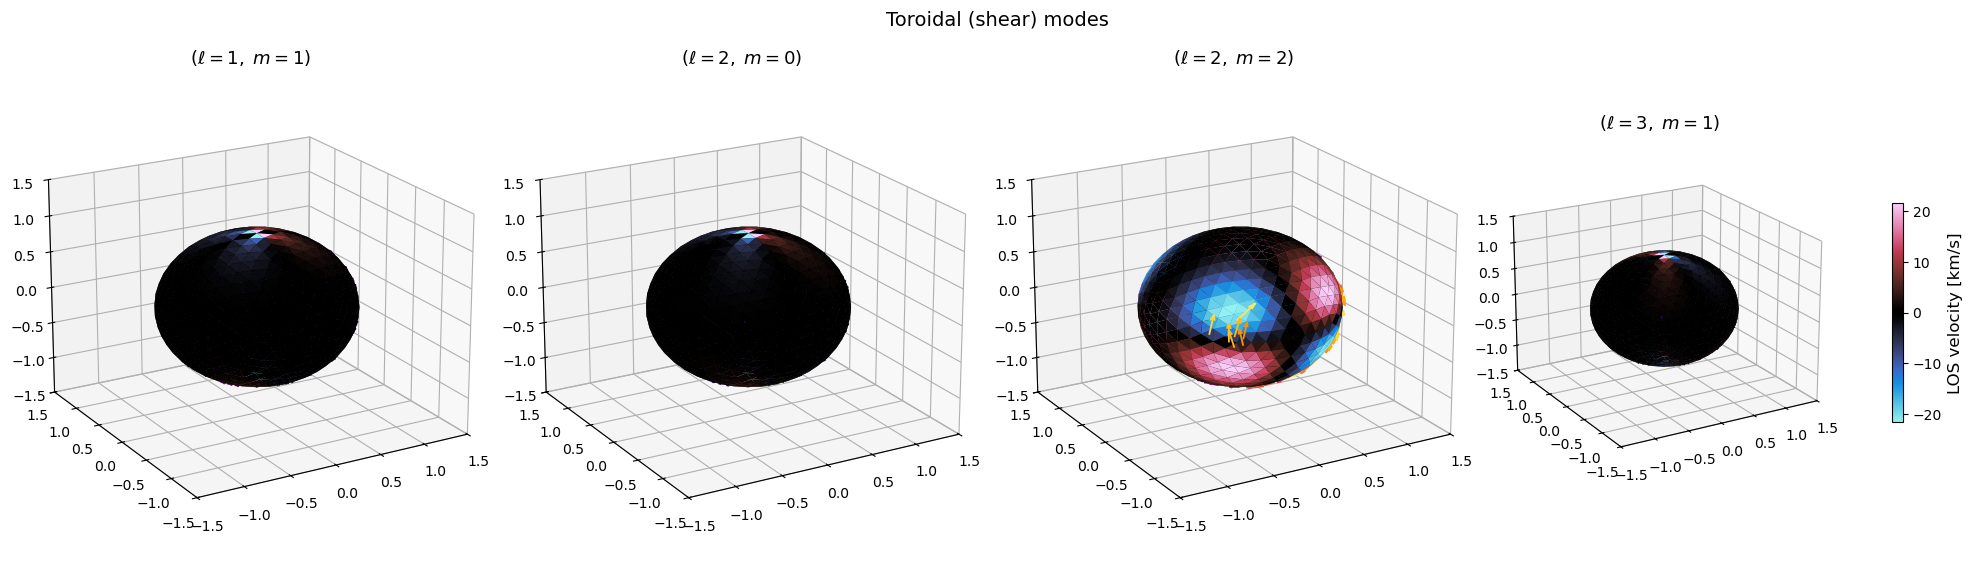

In [8]:
fig = plt.figure(figsize=(20, 5.5))
for i, (l, m) in enumerate(lm_nonradial):
    fp = vsh_fourier(amp_t=0.05)
    m_pulsating = add_pulsation(
        base_mesh, m_order=m, l_degree=l,
        period=PERIOD, fourier_series_parameters=fp,
    )
    mesh_eval = evaluate_pulsations(m_pulsating, t=T_SAMPLE)

    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    plot_3D(mesh_eval, property="los_velocities",
            axes=(fig, ax),
            draw_los_vector=False, draw_rotation_axis=False,
            update_colorbar=(i == 3))
    velocity_arrows(ax, mesh_eval, stride=4, arrow_scale=0.3)
    ax.set_title(rf"$(\ell={l},\; m={m})$", fontsize=13, pad=8)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    ax.view_init(elev=20, azim=-120)

plt.suptitle("Toroidal (shear) modes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Realistic p-mode vs g-mode — the horizontal-to-radial ratio

Real stellar pulsations mix the radial and spheroidal bases. The outer mechanical boundary condition gives a displacement ratio

$$K \;=\; \frac{\xi_h}{\xi_r} \;=\; \frac{GM}{\omega^2 R^3}$$

- **p-modes** are short-period ($\omega$ large) → $K \ll 1$, dominated by the radial component.
- **g-modes** are long-period ($\omega$ small) → $K \gg 1$, dominated by the spheroidal (horizontal) component.

SPICE ships `horizontal_to_radial_ratio(mass, radius, period_days)` which evaluates this for you. We'll use it to build a solar-like p-mode (5-min oscillation) and a SPB g-mode (several-day oscillation).

In [9]:
# Solar-like p-mode: M=1 Msun, R=1 Rsun, P ~ 5 minutes
K_p = float(horizontal_to_radial_ratio(mass=1.0, radius=1.0, pulsation_period=5.0 / 1440.0))
# SPB-like g-mode: M~4 Msun, R~3 Rsun, P ~ 1.5 days
K_g = float(horizontal_to_radial_ratio(mass=4.0, radius=3.0, pulsation_period=1.5))

print(f"K for solar p-mode (5 min):  {K_p:.4e}   (radial-dominated)")
print(f"K for SPB  g-mode  (1.5 d):  {K_g:.4e}   (horizontal-dominated)")

K for solar p-mode (5 min):  8.9875e-04   (radial-dominated)
K for SPB  g-mode  (1.5 d):  2.4849e+01   (horizontal-dominated)


[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s


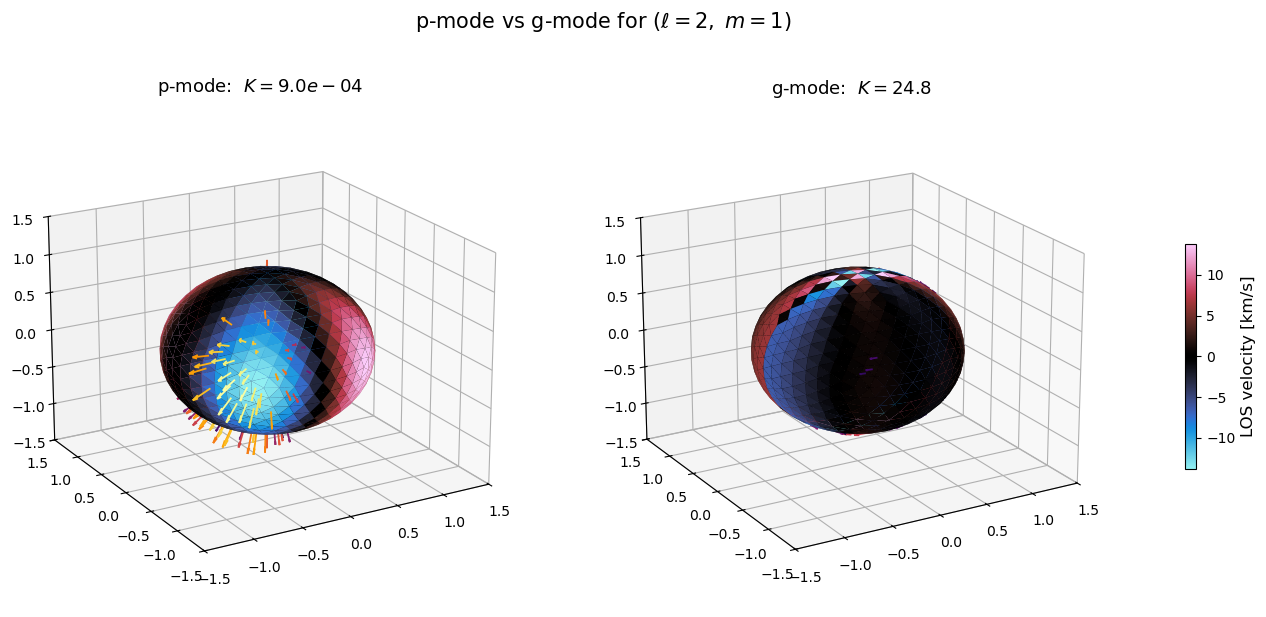


p-mode:  $K=9.0e-04$:  mean tangential fraction = 0.1%
g-mode:  $K=24.8$:  mean tangential fraction = 95.5%


In [10]:
# Build both modes with the same (l, m) so the spatial pattern matches.
# Pick amp_r so the *total* displacement budget stays near 5% of the radius.
AMP = 0.05

cases = {
    rf"p-mode:  $K={K_p:.1e}$":
        vsh_fourier(amp_r=AMP, amp_s=K_p * AMP),
    rf"g-mode:  $K={K_g:.1f}$":
        vsh_fourier(amp_r=AMP / (1.0 + K_g), amp_s=AMP * K_g / (1.0 + K_g)),
}

fig = plt.figure(figsize=(14, 6))
summary = []
for i, (name, fp) in enumerate(cases.items()):
    m_pulsating = add_pulsation(
        base_mesh, m_order=1, l_degree=2,
        period=PERIOD, fourier_series_parameters=fp,
    )
    mesh_eval = evaluate_pulsations(m_pulsating, t=T_SAMPLE)

    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    plot_3D(mesh_eval, property="los_velocities",
            axes=(fig, ax),
            draw_los_vector=False, draw_rotation_axis=False,
            update_colorbar=(i == 1))
    velocity_arrows(ax, mesh_eval, stride=3, arrow_scale=0.35)
    ax.set_title(name, fontsize=13, pad=10)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    ax.view_init(elev=20, azim=-120)

    v_r, v_t = decompose_velocity(mesh_eval)
    v_tot = np.linalg.norm(np.asarray(mesh_eval.pulsation_velocities), axis=1)
    mask = v_tot > 0.01 * v_tot.max()
    frac_tan = (np.linalg.norm(v_t, axis=1)[mask] / v_tot[mask]).mean()
    summary.append((name, frac_tan))

plt.suptitle(r"p-mode vs g-mode for $(\ell=2,\; m=1)$", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print()
for name, frac in summary:
    print(f"{name}:  mean tangential fraction = {frac:.1%}")

## 7. Time evolution of a single mode

Finally, evolve one mode over a full pulsation period to visualize the oscillation. Amplitudes driven by $\cos(2\pi t/P - \phi)$ are at a maximum at $t=0$ (displacement) and at a minimum at $t=P/2$, while the velocity (derivative) is zero at both endpoints and peaks at $t=P/4$ and $t=3P/4$.

[spice] Evaluating pulsations at t=0.0...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.025...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.05...
[spice] Pulsations evaluated in 0.0 s
[spice] Evaluating pulsations at t=0.07500000000000001...
[spice] Pulsations evaluated in 0.0 s


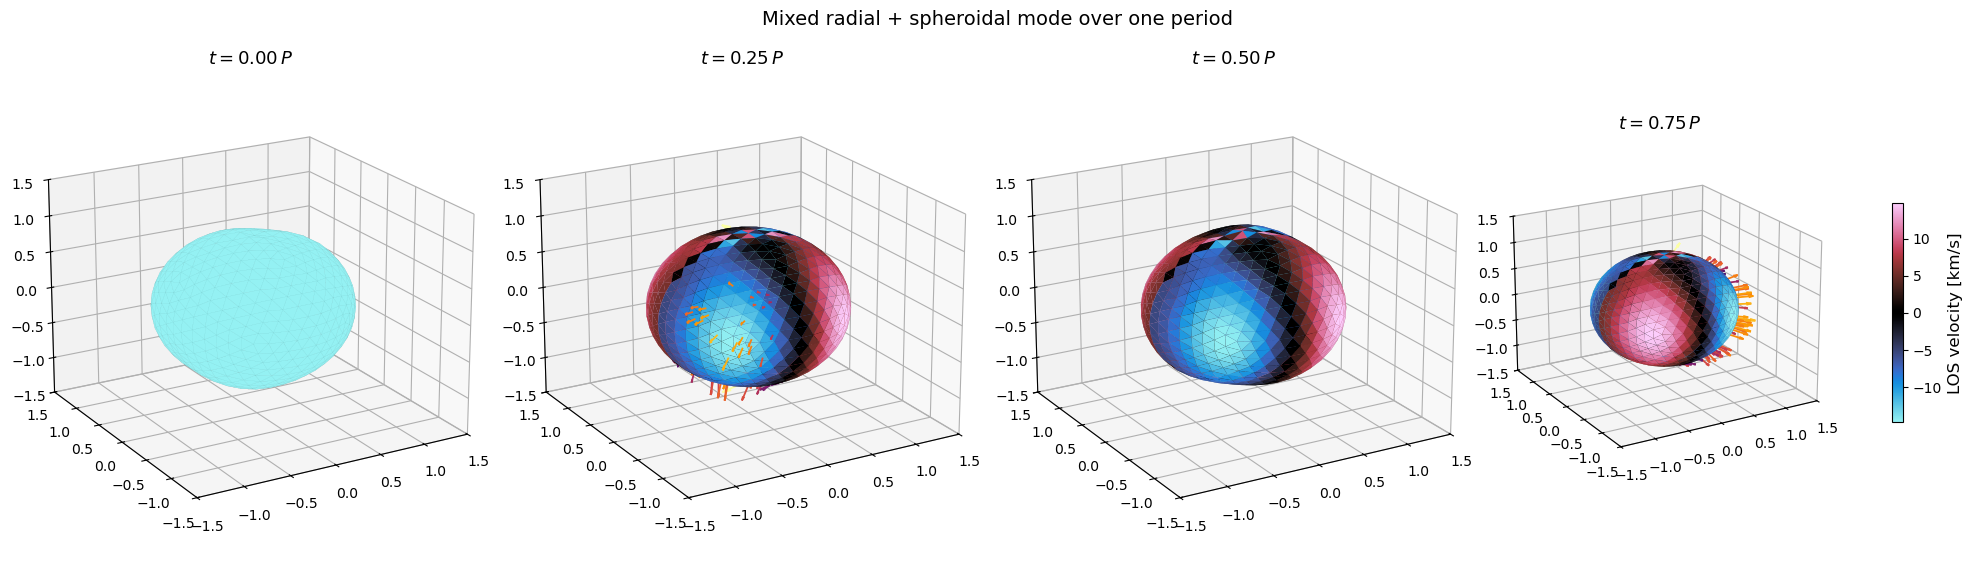

In [11]:
time_fractions = [0.0, 0.25, 0.5, 0.75]
fp_time = vsh_fourier(amp_r=0.04, amp_s=0.04)
m_time = add_pulsation(
    base_mesh, m_order=1, l_degree=2,
    period=PERIOD, fourier_series_parameters=fp_time,
)

fig = plt.figure(figsize=(20, 5.5))
for i, frac in enumerate(time_fractions):
    t = frac * PERIOD
    mesh_eval = evaluate_pulsations(m_time, t=t)
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    plot_3D(mesh_eval, property="los_velocities",
            axes=(fig, ax),
            draw_los_vector=False, draw_rotation_axis=False,
            update_colorbar=(i == 3))
    velocity_arrows(ax, mesh_eval, stride=4, arrow_scale=0.3)
    ax.set_title(rf"$t = {frac:.2f}\,P$", fontsize=13, pad=8)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    ax.view_init(elev=20, azim=-120)

plt.suptitle("Mixed radial + spheroidal mode over one period", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Recap

- A single call to `add_pulsation(mesh, m_order, l_degree, period, fourier_series_parameters=...)` installs one VSH mode on the mesh.
- The Fourier-parameter array has shape `(3, n_terms, 2)`; the first axis is always `[radial, spheroidal, toroidal]`, and zeros turn a component off.
- `reset_pulsations(mesh)` wipes every installed mode if you want to start over.
- For multiple simultaneous modes, use `add_pulsations(...)` (plural), which accepts stacked arrays of the same shape.
- Use `horizontal_to_radial_ratio(M, R, P)` to convert stellar parameters into the $K$ needed to balance radial vs spheroidal amplitudes for realistic p- and g-modes.